In [7]:
import numpy as np
import matplotlib.pyplot as plt

In [8]:
# y_t = p * y_{t-1} + b* X_t + e_t

np.random.seed(42)

T = 500
k = 2

rho = np.array([0.2, 0.8])
beta = np.array([1.5, -0.5])
sigma = np.array([0.5, 1.0])

P = np.array([
    [0.95, 0.05],
    [0.05, 0.95]
])

X = np.random.normal(loc=0, scale=1, size=T)
states = np.zeros(T, dtype=int)
y = np.zeros(T)

states[0] = np.random.choice(k)
y[0] = np.random.normal(scale=sigma[states[0]])

for t in range(1, T):
    states[t] = np.random.choice(k, p=P[states[t-1]])
    s = states[t]

    y[t] = rho[s]*y[t-1] + beta[s]*X[t] + np.random.normal(scale=sigma[s])

    if t % 100 == 0:
        print(f"t={t:<5} state: {s:<3} X: {X[t]:>6.2f} y: {y[t]:>6.2f}")



t=100   state: 1   X:  -1.42 y:   3.01
t=200   state: 0   X:   0.36 y:   0.29
t=300   state: 0   X:  -0.83 y:  -1.87
t=400   state: 0   X:  -1.59 y:  -0.79


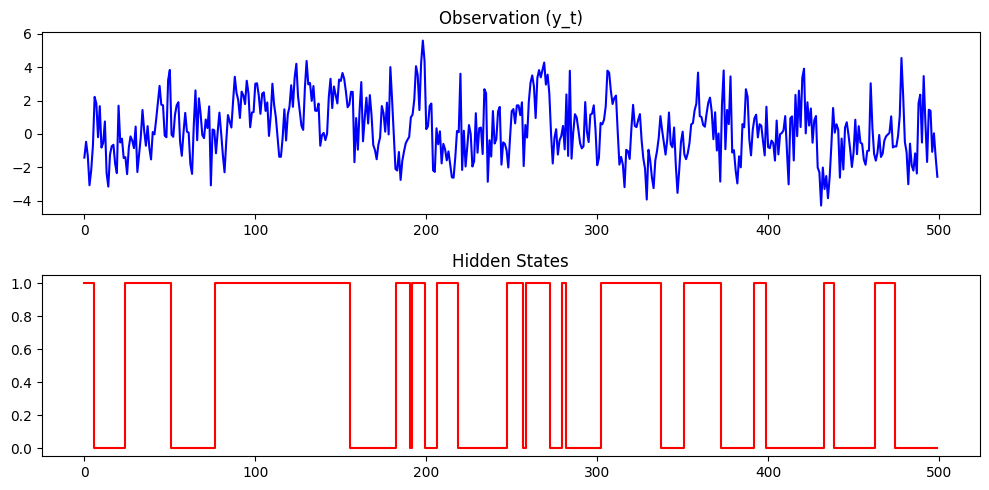

In [9]:
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(10, 5))

ax1.plot(y, color='blue')
ax1.set_title("Observation (y_t)")

ax2.plot(states, color='red', drawstyle='steps-mid')
ax2.set_title("Hidden States")

plt.tight_layout()
plt.show()